# Mid-Block Expansion Evaluation on GSM8K

评测 **Dual Cache + Mid-Block Chain Expansion** 在 GSM8K 上的效果。

**四组实验（4 个 GPU 并行）：**
1. **Expand (no rewarm, fallback off)**
2. **Expand (no rewarm, fallback on)**
3. **Expand (rewarm, fallback off)**
4. **Expand (rewarm, fallback on)**

其中 fallback 对应参数 `front_block_fallback_only`。

**核心指标：**
- GSM8K 准确率（100 题）
- 每步解码 token 数量分布（通过 step_records 收集）
- 总 NFE 对比

## 1. 环境设置

In [4]:
import os
import torch
import gc

# Set GPU (modify as needed)
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2,3,4,5,6,7'

# Environment settings
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
os.environ['HF_ALLOW_CODE_EVAL'] = '1'
os.environ['HF_DATASETS_TRUST_REMOTE_CODE'] = 'true'

# Change to llada directory
os.chdir('llada')

# Create log directory
os.makedirs('nlogs', exist_ok=True)

# Clear GPU cache
torch.cuda.empty_cache()
gc.collect()

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

FileNotFoundError: [Errno 2] No such file or directory: 'llada'

## 2. 三组实验并行启动（3 个 GPU）

每个 config 在不同 GPU 上并行运行 100 题 GSM8K。

**`step_records_dir`** 用于保存每步解码统计信息（JSON），供后续可视化使用。

In [ ]:
import subprocess
import datetime

task = "gsm8k"
fewshot = 5
limit = 100
seed = 42
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# ========== 通用生成参数 ==========
gen_length = 256
steps = 256
block_length = 32
threshold = 0.9

# ========== 四组配置: rewarm/no_rewarm × front_block_fallback_only 开关 ==========
configs = [
    (0, "expand_no_rewarm_fb_off", [
        "dual_cache=True",
        "mid_block_expand=True",
        "mid_trigger_ratio=0.5",
        "rewarm_on_expand=False",
        "front_block_fallback_only=False",
    ]),
    (1, "expand_no_rewarm_fb_on", [
        "dual_cache=True",
        "mid_block_expand=True",
        "mid_trigger_ratio=0.5",
        "rewarm_on_expand=False",
        "front_block_fallback_only=True",
    ]),
    (2, "expand_rewarm_fb_off", [
        "dual_cache=True",
        "mid_block_expand=True",
        "mid_trigger_ratio=0.5",
        "rewarm_on_expand=True",
        "front_block_fallback_only=False",
    ]),
    (3, "expand_rewarm_fb_on", [
        "dual_cache=True",
        "mid_block_expand=True",
        "mid_trigger_ratio=0.5",
        "rewarm_on_expand=True",
        "front_block_fallback_only=True",
    ]),
]

processes = []

for gpu, name, extra_args in configs:
    log_file = f"nlogs/expand_{task}_{name}_{timestamp}.log"
    output_dir = f"evals_results/expand/{task}-{name}-{timestamp}"
    records_dir = f"evals_results/expand/{task}-{name}-{timestamp}/step_records"

    base_args = [
        f"model_path='GSAI-ML/LLaDA-8B-Instruct'",
        f"gen_length={gen_length}",
        f"steps={steps}",
        f"block_length={block_length}",
        f"threshold={threshold}",
        "use_cache=True",
        "show_speed=True",
        f"step_records_dir='{records_dir}'",
        f"seed={seed}",
    ]
    all_args = base_args + extra_args
    model_args_str = ",".join(all_args)

    cmd = (
        f"CUDA_VISIBLE_DEVICES={gpu} accelerate launch eval_llada.py "
        f"--tasks {task} --num_fewshot {fewshot} --limit {limit} "
        f"--confirm_run_unsafe_code --model llada_dist "
        f"--model_args {model_args_str} "
        f"--output_path {output_dir} --log_samples"
    )

    print(f"GPU {gpu} | {name}")
    print(f"  Log: {log_file}")
    print(f"  Cmd: {cmd[:180]}...")
    print()

    p = subprocess.Popen(cmd, shell=True, stdout=open(log_file, "w"), stderr=subprocess.STDOUT)
    processes.append((p, name, log_file, output_dir))

print(f"\n{len(processes)} tasks launched in parallel, waiting...")

In [ ]:
# 等待所有进程完成
for p, name, log, out_dir in processes:
    p.wait()
    rc = p.returncode
    status = "OK" if rc == 0 else f"FAILED (exit {rc})"
    print(f"{name}: {status}")

    # 显示最后 10 行日志
    with open(log, 'r') as f:
        lines = f.readlines()
    print(f"  Last lines:")
    for line in lines[-10:]:
        print(f"    {line.rstrip()}")
    print()

## 3. 解析评测结果

In [ ]:
import glob
import re
import json
import numpy as np
import pandas as pd

# 从 log 文件中提取指标
log_files = sorted(glob.glob(f"nlogs/expand_{task}_*_{timestamp}.log"))

print(f"Mid-Block Expansion GSM8K Results (timestamp={timestamp}):")
print("=" * 90)

parsed_results = []
for log_file in log_files:
    fname = os.path.basename(log_file)
    # 从文件名中提取 config name
    # 格式: expand_gsm8k_{name}_{timestamp}.log
    name_part = fname.replace(f"expand_{task}_", "").replace(f"_{timestamp}.log", "")

    with open(log_file, 'r') as f:
        content = f.read()

    # 提取准确率 (lm-eval 输出格式)
    acc_match = re.search(r'exact_match.*?[\|,]\s*[\|]?\s*([\d.]+)', content)
    acc = float(acc_match.group(1)) if acc_match else None

    # 提取速度信息
    speed_match = re.search(r'Tokens per second:\s*([\d.]+)', content)
    speed = float(speed_match.group(1)) if speed_match else None

    nfe_match = re.search(r'Total NFE is (\d+)', content)
    nfe = int(nfe_match.group(1)) if nfe_match else None

    time_match = re.search(r'Total time taken:\s*([\d.]+)', content)
    time_sec = float(time_match.group(1)) if time_match else None

    parsed_results.append({
        'config': name_part,
        'accuracy': acc,
        'tokens_per_sec': speed,
        'total_nfe': nfe,
        'time_sec': time_sec,
        'log_file': log_file,
    })

# 格式化输出
print(f"{'Config':<25} {'Acc':<10} {'Tok/s':<12} {'Total NFE':<12} {'Time(s)':<10}")
print("-" * 70)
for r in parsed_results:
    acc_str = f"{r['accuracy']:.4f}" if r['accuracy'] is not None else "N/A"
    speed_str = f"{r['tokens_per_sec']:.1f}" if r['tokens_per_sec'] is not None else "N/A"
    nfe_str = str(r['total_nfe']) if r['total_nfe'] is not None else "N/A"
    time_str = f"{r['time_sec']:.1f}" if r['time_sec'] is not None else "N/A"
    print(f"{r['config']:<25} {acc_str:<10} {speed_str:<12} {nfe_str:<12} {time_str:<10}")

df_summary = pd.DataFrame(parsed_results)
display(df_summary)

## 4. 加载 Step Records（per-step 解码统计）

In [ ]:
# 加载各配置的 step_records.json
config_labels = {
    'expand_no_rewarm_fb_off': 'Expand (no rewarm, fb off)',
    'expand_no_rewarm_fb_on': 'Expand (no rewarm, fb on)',
    'expand_rewarm_fb_off': 'Expand (rewarm, fb off)',
    'expand_rewarm_fb_on': 'Expand (rewarm, fb on)',
}
colors = {
    'expand_no_rewarm_fb_off': '#FFB74D',
    'expand_no_rewarm_fb_on': '#FB8C00',
    'expand_rewarm_fb_off': '#81C784',
    'expand_rewarm_fb_on': '#2E7D32',
}

step_data = {}  # config_name -> list of per-sample step records

for _, name, _, out_dir in processes:
    records_path = os.path.join(out_dir, 'step_records', 'step_records.json')
    if os.path.exists(records_path):
        with open(records_path, 'r') as f:
            step_data[name] = json.load(f)
        print(f"Loaded {name}: {len(step_data[name])} samples, "
              f"total steps = {sum(len(s) for s in step_data[name])}")
    else:
        print(f"WARNING: {records_path} not found (config={name})")

print(f"\nLoaded step records for {len(step_data)} configs.")

## 5. 每步解码 Token 数量（核心图表）

每个 config 在每个 global_step 上平均解码了多少 token。

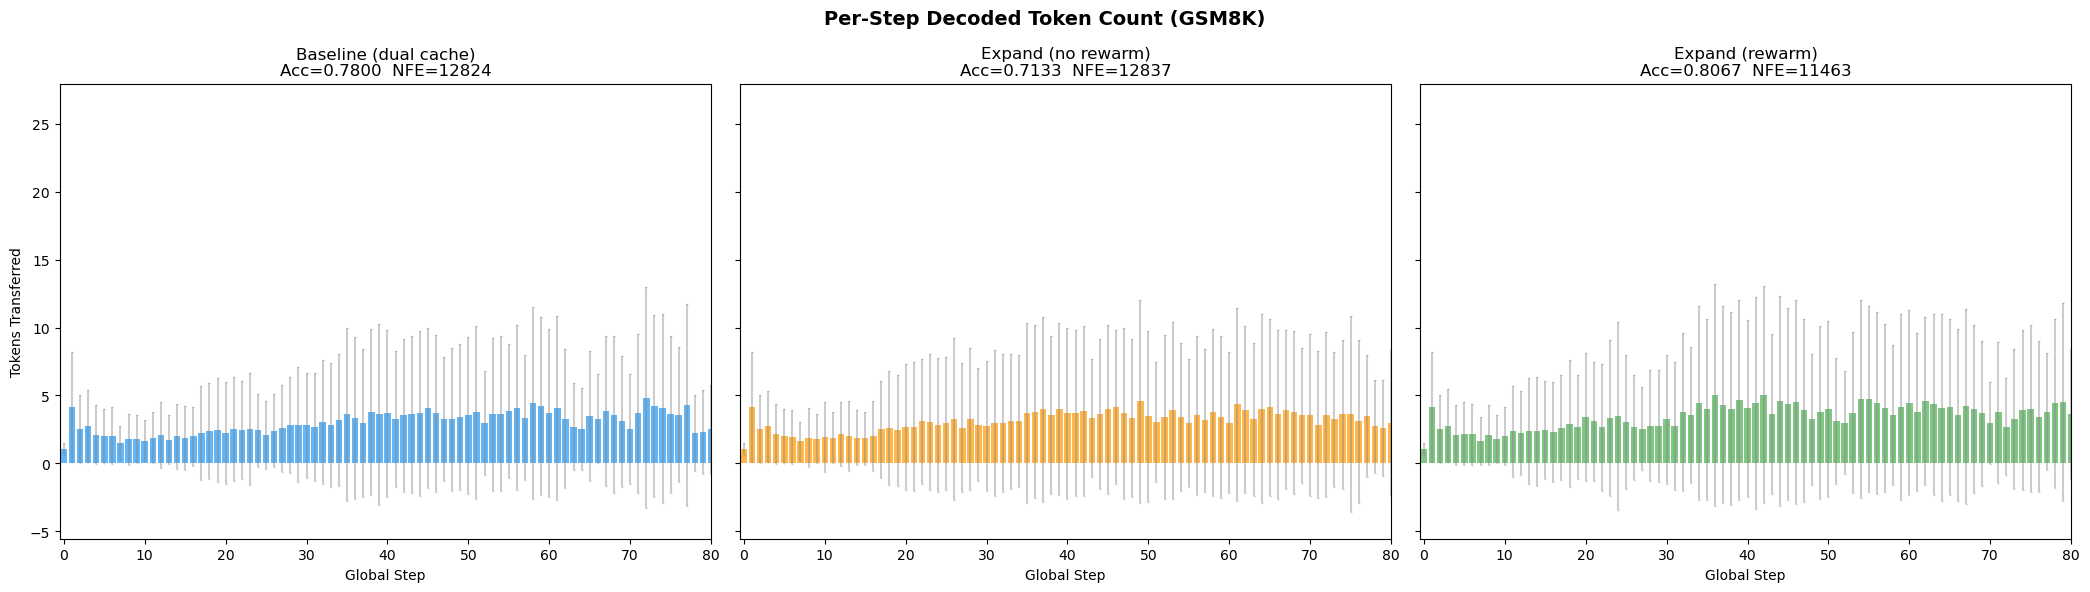

Saved: eval_results/per_step_tokens.png


In [6]:
import matplotlib.pyplot as plt
from collections import defaultdict

# --- 分 config 的 per-step 柱状图 ---
fig, axes = plt.subplots(1, len(step_data), figsize=(7 * len(step_data), 6), sharey=True)
if len(step_data) == 1:
    axes = [axes]

for ax_idx, (cname, samples) in enumerate(step_data.items()):
    ax = axes[ax_idx]
    
    step_transferred = defaultdict(list)
    for sample_records in samples:
        for r in sample_records:
            step_transferred[r['global_step']].append(r['transferred'])
    
    max_step = max(step_transferred.keys()) if step_transferred else 0
    steps_range = list(range(max_step + 1))
    means = [np.mean(step_transferred[s]) if s in step_transferred else 0 for s in steps_range]
    stds  = [np.std(step_transferred[s])  if s in step_transferred else 0 for s in steps_range]
    
    ax.bar(steps_range, means, color=colors.get(cname, 'gray'), alpha=0.7)
    ax.errorbar(steps_range, means, yerr=stds, fmt='none', ecolor='gray', alpha=0.4, capsize=1)
    ax.set_xlabel('Global Step')
    label = config_labels.get(cname, cname)
    
    # 从 parsed_results 拿 accuracy
    acc_info = next((r for r in parsed_results if r['config'] == cname), None)
    acc_str = f"Acc={acc_info['accuracy']:.4f}" if acc_info and acc_info['accuracy'] else ""
    nfe_str = f"NFE={acc_info['total_nfe']}" if acc_info and acc_info['total_nfe'] else ""
    ax.set_title(f"{label}\n{acc_str}  {nfe_str}")
    ax.set_xlim(-0.5, max_step + 0.5)

axes[0].set_ylabel('Tokens Transferred')
fig.suptitle('Per-Step Decoded Token Count (GSM8K)', fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs('../eval_results', exist_ok=True)
plt.savefig('../eval_results/per_step_tokens.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eval_results/per_step_tokens.png")

## 6. 三组叠加对比（均值线图 + 标准差带）

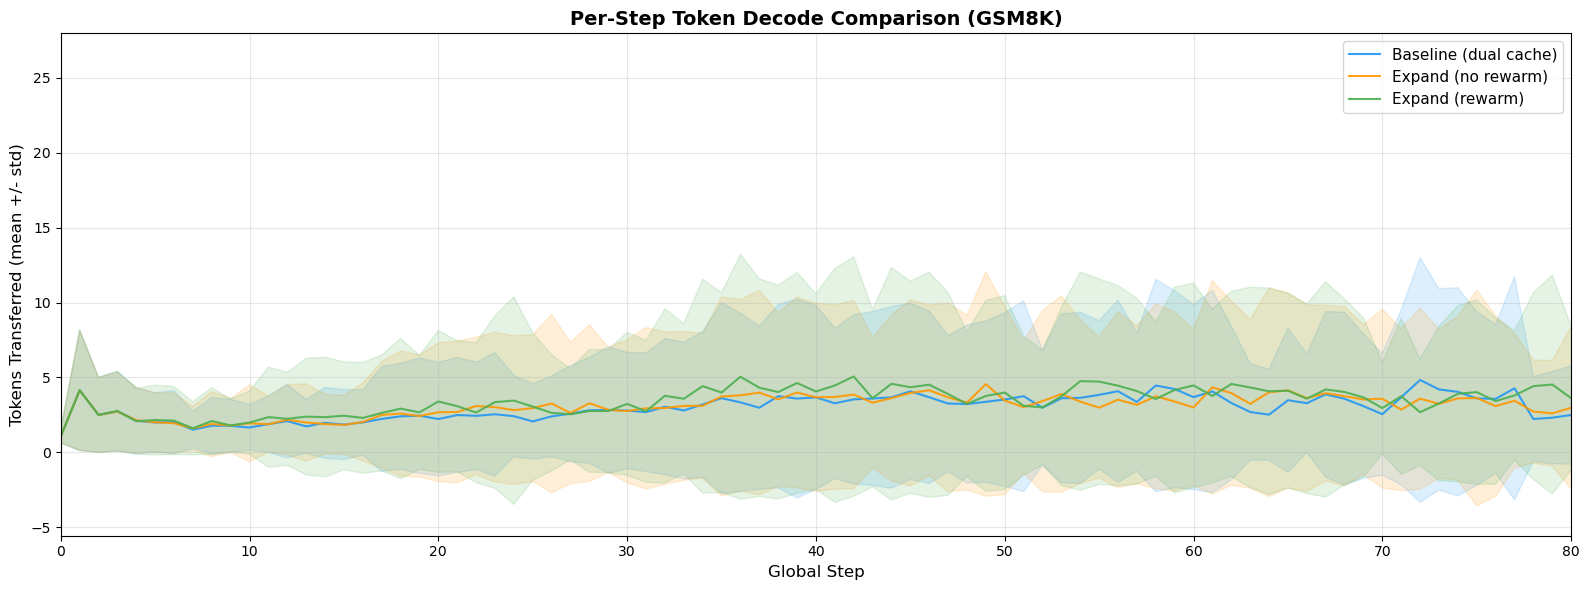

In [7]:
fig, ax = plt.subplots(figsize=(16, 6))

for cname, samples in step_data.items():
    step_transferred = defaultdict(list)
    for sample_records in samples:
        for r in sample_records:
            step_transferred[r['global_step']].append(r['transferred'])
    
    max_step = max(step_transferred.keys()) if step_transferred else 0
    steps_range = list(range(max_step + 1))
    means = [np.mean(step_transferred[s]) if s in step_transferred else 0 for s in steps_range]
    stds  = [np.std(step_transferred[s])  if s in step_transferred else 0 for s in steps_range]
    
    label = config_labels.get(cname, cname)
    color = colors.get(cname, 'gray')
    ax.plot(steps_range, means, label=label, color=color, linewidth=1.5, alpha=0.9)
    ax.fill_between(steps_range,
                     [m - s for m, s in zip(means, stds)],
                     [m + s for m, s in zip(means, stds)],
                     color=color, alpha=0.15)

ax.set_xlabel('Global Step', fontsize=12)
ax.set_ylabel('Tokens Transferred (mean +/- std)', fontsize=12)
ax.set_title('Per-Step Token Decode Comparison (GSM8K)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../eval_results/per_step_tokens_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Step 类型分布（warm / refine / expand）

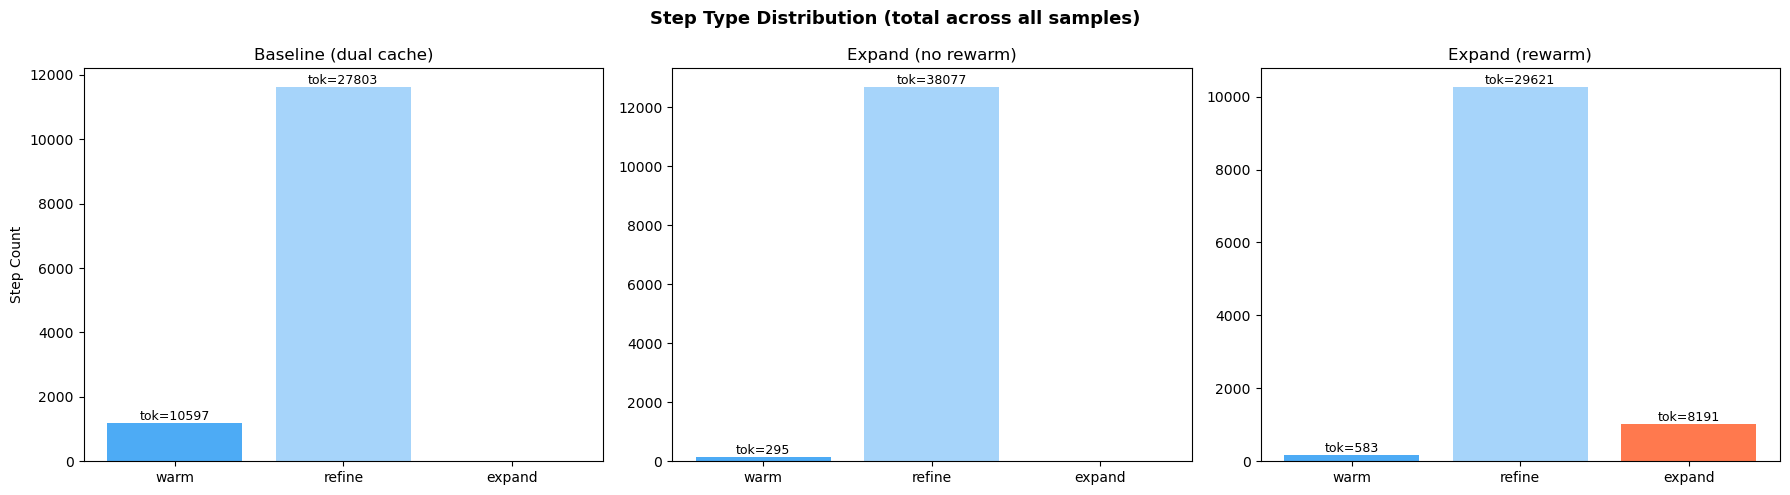

In [8]:
fig, axes = plt.subplots(1, len(step_data), figsize=(6 * len(step_data), 5))
if len(step_data) == 1:
    axes = [axes]

type_colors = {'warm': '#2196F3', 'refine': '#90CAF9', 'expand': '#FF5722'}

for ax_idx, (cname, samples) in enumerate(step_data.items()):
    ax = axes[ax_idx]
    
    type_counts = defaultdict(int)
    type_transferred = defaultdict(int)
    for sample_records in samples:
        for r in sample_records:
            type_counts[r['type']] += 1
            type_transferred[r['type']] += r['transferred']
    
    types = ['warm', 'refine', 'expand']
    counts = [type_counts.get(t, 0) for t in types]
    transferred = [type_transferred.get(t, 0) for t in types]
    
    x_pos = np.arange(len(types))
    bars = ax.bar(x_pos, counts, color=[type_colors[t] for t in types], alpha=0.8)
    
    for bar, t_count in zip(bars, transferred):
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'tok={t_count}', ha='center', va='bottom', fontsize=9)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(types)
    ax.set_title(config_labels.get(cname, cname))
    ax.set_ylabel('Step Count' if ax_idx == 0 else '')

fig.suptitle('Step Type Distribution (total across all samples)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../eval_results/step_type_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 累计解码进度曲线

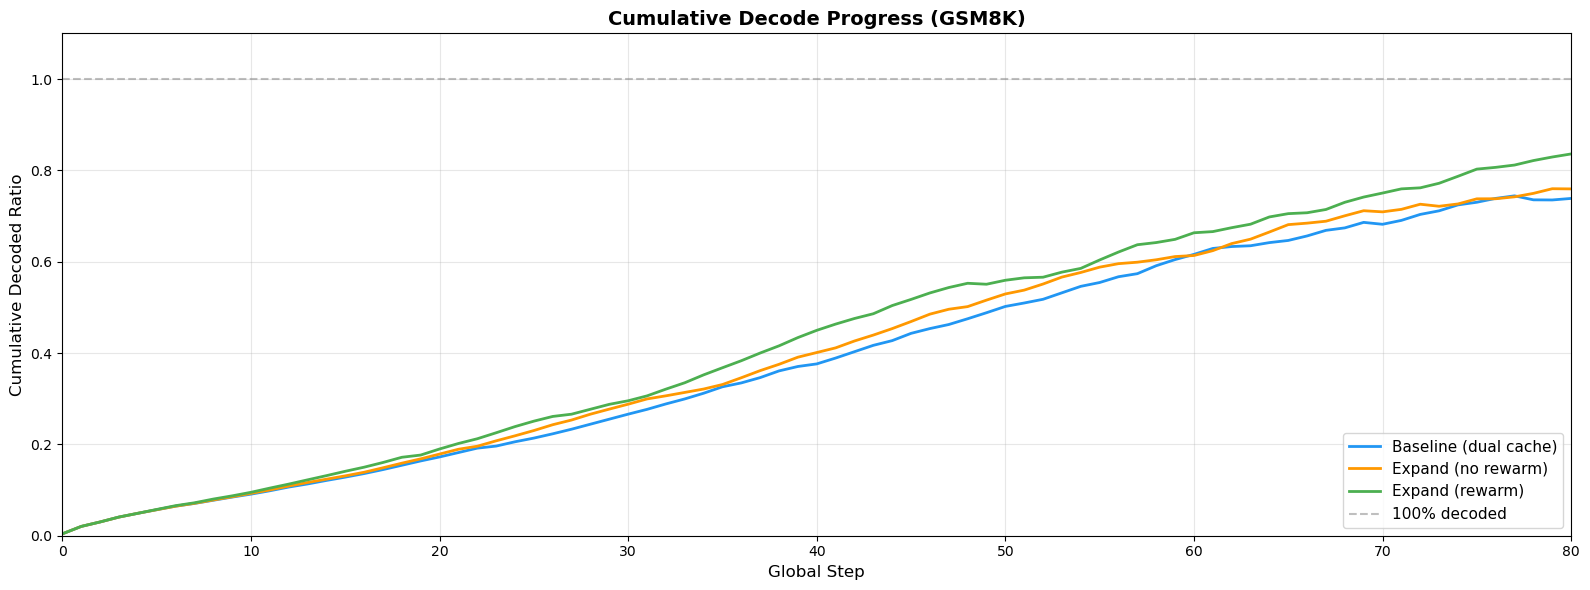

In [9]:
fig, ax = plt.subplots(figsize=(16, 6))

for cname, samples in step_data.items():
    # 对每个样本，构建完整的 step→ratio 映射，已完成的样本填充 1.0
    max_step_all = max(r['global_step'] for sr in samples for r in sr)
    n_samples = len(samples)
    
    # 每个样本的 per-step ratio（补齐到 max_step_all，完成后填 1.0）
    all_ratios = np.ones((n_samples, max_step_all + 1))  # 默认 1.0
    for si, sample_records in enumerate(samples):
        cum = 0
        last_step = 0
        for r in sample_records:
            # 填充该 step 之前的空隙（如果有的话）
            ratio = min(cum / gen_length, 1.0)
            for fill_s in range(last_step, r['global_step']):
                all_ratios[si, fill_s] = ratio
            cum += r['transferred']
            all_ratios[si, r['global_step']] = min(cum / gen_length, 1.0)
            last_step = r['global_step'] + 1
        # last_step 之后自动是 1.0（np.ones 默认值）
    
    means = all_ratios.mean(axis=0)
    steps_range = list(range(max_step_all + 1))
    
    label = config_labels.get(cname, cname)
    ax.plot(steps_range, means, label=label, color=colors.get(cname, 'gray'), linewidth=2)

ax.set_xlabel('Global Step', fontsize=12)
ax.set_ylabel('Cumulative Decoded Ratio (mean over samples)', fontsize=12)
ax.set_title('Cumulative Decode Progress (GSM8K)', fontsize=14, fontweight='bold')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='100% decoded')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../eval_results/cumulative_decode.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. NFE 对比柱状图

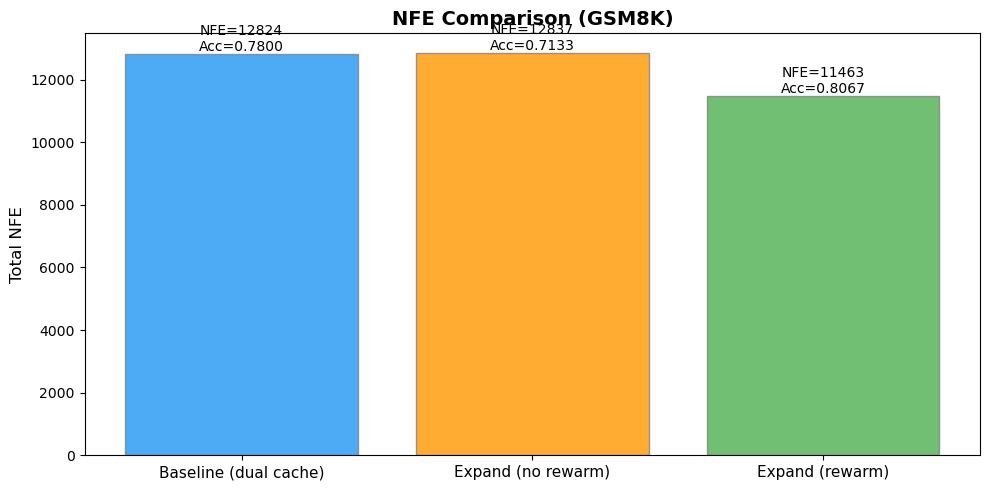

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

positions = np.arange(len(parsed_results))
nfe_values = [r['total_nfe'] or 0 for r in parsed_results]
acc_values = [r['accuracy'] or 0 for r in parsed_results]
labels = [config_labels.get(r['config'], r['config']) for r in parsed_results]
bar_colors = [colors.get(r['config'], 'gray') for r in parsed_results]

bars = ax.bar(positions, nfe_values, color=bar_colors, alpha=0.8, edgecolor='gray')

for bar, nfe_val, acc_val in zip(bars, nfe_values, acc_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'NFE={nfe_val}\nAcc={acc_val:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Total NFE', fontsize=12)
ax.set_title('NFE Comparison (GSM8K)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../eval_results/nfe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. 从已有结果重新加载（跨机器/补跑用）

如果在其他服务器上单独跑完了某个 config，把 `evals_results/expand/` 和 `nlogs/` 拷过来后，修改下面的 `timestamp` 即可重新加载并重新生成所有图表。

In [5]:
import glob, re, json, os
import numpy as np
import pandas as pd

task = "gsm8k"
gen_length = 256

config_names = [
    'expand_no_rewarm_fb_off',
    'expand_no_rewarm_fb_on',
    'expand_rewarm_fb_off',
    'expand_rewarm_fb_on',
]
config_labels = {
    'expand_no_rewarm_fb_off': 'Expand (no rewarm, fb off)',
    'expand_no_rewarm_fb_on': 'Expand (no rewarm, fb on)',
    'expand_rewarm_fb_off': 'Expand (rewarm, fb off)',
    'expand_rewarm_fb_on': 'Expand (rewarm, fb on)',
}
colors = {
    'expand_no_rewarm_fb_off': '#FFB74D',
    'expand_no_rewarm_fb_on': '#FB8C00',
    'expand_rewarm_fb_off': '#81C784',
    'expand_rewarm_fb_on': '#2E7D32',
}

# 自动找最新的 timestamp（从某个新配置 log 文件名中提取）
latest_logs = sorted(glob.glob(f"nlogs/expand_{task}_{config_names[0]}_*.log"), key=os.path.getmtime, reverse=True)
if latest_logs:
    # 从文件名提取 timestamp
    fname = os.path.basename(latest_logs[0])
    timestamp = fname.replace(f"expand_{task}_{config_names[0]}_", "").replace(".log", "")
    print(f"Auto-detected latest timestamp: {timestamp}")
else:
    timestamp = "NOTFOUND"
    print("WARNING: No log found for the new 4-config setup!")

# 加载 step_data
step_data = {}
for name in config_names:
    rpath = f"evals_results/expand/{task}-{name}-{timestamp}/step_records/step_records.json"
    if os.path.exists(rpath):
        with open(rpath, 'r') as f:
            step_data[name] = json.load(f)
        print(f"  {name}: {len(step_data[name])} samples, {sum(len(s) for s in step_data[name])} total steps")
    else:
        print(f"  {name}: step_records NOT FOUND at {rpath}")

# 加载 parsed_results
parsed_results = []
for name in config_names:
    log_file = f"nlogs/expand_{task}_{name}_{timestamp}.log"
    if not os.path.exists(log_file):
        print(f"  {name}: log NOT FOUND")
        continue
    with open(log_file, 'r') as f:
        content = f.read()
    acc_match = re.search(r'exact_match.*?[\|,]\s*[\|]?\s*([\d.]+)', content)
    nfe_match = re.search(r'Total NFE is (\d+)', content)
    time_match = re.search(r'Total time taken:\s*([\d.]+)', content)
    speed_match = re.search(r'Tokens per second:\s*([\d.]+)', content)
    parsed_results.append({
        'config': name,
        'accuracy': float(acc_match.group(1)) if acc_match else None,
        'total_nfe': int(nfe_match.group(1)) if nfe_match else None,
        'time_sec': float(time_match.group(1)) if time_match else None,
        'tokens_per_sec': float(speed_match.group(1)) if speed_match else None,
    })
    acc_str = f"{parsed_results[-1]['accuracy']:.4f}" if parsed_results[-1]['accuracy'] else "N/A"
    nfe_str = str(parsed_results[-1]['total_nfe']) if parsed_results[-1]['total_nfe'] else "N/A"
    print(f"  {name}: acc={acc_str}, nfe={nfe_str}")

print(f"\nLoaded {len(step_data)} step_data, {len(parsed_results)} parsed_results")
print("Now re-run Section 5~9 cells to regenerate all plots.")

Auto-detected latest timestamp: 20260214_013617
  baseline: 150 samples, 12824 total steps
  expand_no_rewarm: 150 samples, 12837 total steps
  expand_rewarm: 150 samples, 11463 total steps
  baseline: acc=0.7800, nfe=12824
  expand_no_rewarm: acc=0.7133, nfe=12837
  expand_rewarm: acc=0.8067, nfe=11463

Loaded 3 step_data, 3 parsed_results
Now re-run Section 5~9 cells to regenerate all plots.
